### Redes neuronales artificiales

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

2025-05-05 16:18:44.076321: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-05 16:18:44.080073: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-05 16:18:44.092029: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746479924.112392    6269 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746479924.118440    6269 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746479924.134175    6269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
from IPython.display import Image
from tensorflow.keras.datasets import fashion_mnist

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
x_test.shape

(10000, 28, 28)

In [6]:
y_test

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

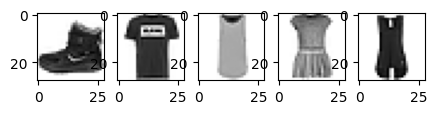

In [7]:
plt.figure(figsize = (5,5))
for i, imagen in enumerate(x_train[0:5]):
    plt.subplot(1,5,i+1)
    plt.imshow(imagen, cmap = plt.cm.binary)

In [8]:
x_train = x_train/255
x_test = x_test/255

In [9]:
x_train = x_train.reshape((x_train.shape[0]),28, 28).astype('float32')
x_test = x_test.reshape((x_test.shape[0]),28, 28).astype('float32')

In [11]:
model = tf.keras.models.Sequential()

In [12]:
model.add(tf.keras.layers.Flatten(input_shape = [28,28]))

/home/fisica8/anaconda3/envs/David_Luque/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.add(tf.keras.layers.Dense(300, activation = 'relu' ))
model.add(tf.keras.layers.Dense(100, activation = 'relu'))
model.add(tf.keras.layers.Dense(10, activation = 'softmax'))

2025-05-05 16:18:48.864180: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-05-05 16:18:48.864229: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-05-05 16:18:48.864242: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: fisica8-iMac
2025-05-05 16:18:48.864252: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] hostname: fisica8-iMac
2025-05-05 16:18:48.864388: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:197] libcuda reported version is: 390.157.0
2025-05-05 16:18:48.864434: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:201] kernel reported version is: 390.1

In [16]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['sparse_categorical_accuracy'])

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.fit(x_train, y_train, epochs = 5)

Epoch 1/5


2025-05-05 16:18:49.910283: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.5878 - sparse_categorical_accuracy: 0.7937
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.3729 - sparse_categorical_accuracy: 0.8628
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.3245 - sparse_categorical_accuracy: 0.8795
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.3026 - sparse_categorical_accuracy: 0.8895
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2809 - sparse_categorical_accuracy: 0.8939


In [19]:
loss, accuracy = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3327 - sparse_categorical_accuracy: 0.8807   


In [21]:
index = np.random.randint(0,100,1)
index

array([48])

In [23]:
x_testing = x_train[index]
y_p = model.predict(x_testing)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [24]:
y_p

array([[9.9969423e-01, 4.2573708e-11, 5.4731750e-06, 9.2749337e-07,
        4.8848831e-10, 4.5821221e-16, 2.9935947e-04, 2.1775218e-20,
        6.9075481e-11, 8.5215915e-17]], dtype=float32)

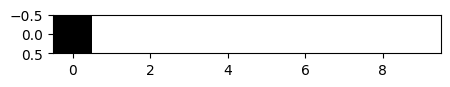

In [26]:
plt.figure(figsize = (5,5))
plt.imshow(y_p,cmap = plt.cm.binary)


In [27]:
y_train[index]

array([0], dtype=uint8)

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

In [32]:
from tensorflow.keras.datasets import mnist

In [33]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step


In [34]:
x_train.shape

(60000, 28, 28)

In [35]:
x_test.shape

(10000, 28, 28)

In [36]:
x_train = x_train.reshape((x_train.shape[0], 28, 28)).astype('float32')/255
x_test = x_test.reshape((x_test.shape[0], 28, 28)).astype('float32')/255

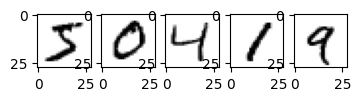

In [37]:
plt.figure(figsize = (4,3))
for i, imagen in enumerate(x_train[0:5]):
    plt.subplot(1,5,i+1)
    plt.imshow(imagen, cmap = plt.cm.binary)


In [38]:
model = Sequential()

In [41]:
model.add(Flatten(input_shape = [28,28]))
model.add(Dense(300, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(80, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))

In [42]:
model.compile(optimizer = 'adam', 
              loss = 'sparse_categorical_crossentropy', 
              metrics = ['sparse_categorical_accuracy'])

In [43]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 80)             │        24,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 350,690 (1.34 MB)

 Trainable params: 350,690 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
model.fit(x_train, y_train, epochs = 5)

Epoch 1/5


2025-05-05 16:48:35.744765: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.4295 - sparse_categorical_accuracy: 0.8649
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1244 - sparse_categorical_accuracy: 0.9631
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0922 - sparse_categorical_accuracy: 0.9712 
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0760 - sparse_categorical_accuracy: 0.9755
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0659 - sparse_categorical_accuracy: 0.9797


In [45]:
loss, accuracy = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0945 - sparse_categorical_accuracy: 0.9730   


In [50]:
index = np.random.randint(0,100,1)
x_testing = x_train[index]
y_p1 = model.predict(x_testing)
y_p1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[2.0362170e-04, 1.9267236e-07, 2.0846753e-06, 5.4718282e-07,
        2.8374683e-04, 1.3327368e-05, 9.9948311e-01, 3.0980704e-07,
        6.4225255e-06, 6.6547386e-06]], dtype=float32)

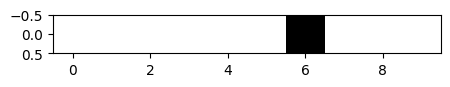

In [53]:
plt.figure(figsize = (5,5))
plt.imshow(y_p1,cmap = plt.cm.binary)

In [52]:
y_train[index]

array([6], dtype=uint8)

In [64]:
y_pred = model.predict(x_test[[15]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [65]:
y_pred

array([[2.3793771e-09, 3.0309096e-08, 1.7643567e-08, 2.5749714e-03,
        3.0360112e-09, 9.9741995e-01, 1.1987679e-08, 3.1946615e-11,
        4.3459542e-07, 4.6232653e-06]], dtype=float32)

In [66]:
np.argmax(y_pred)

np.int64(5)

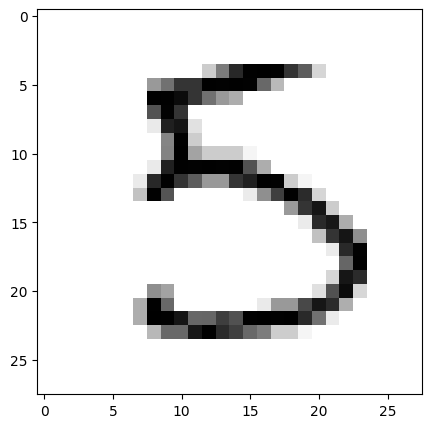

In [67]:
plt.figure(figsize = (5,5))
plt.imshow(x_test[15],cmap = plt.cm.binary)